# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

In [2]:
# Preparing Functions / Data Extraction

# Read out an Analog Scan
def Read_Analog(path):

    skip = 22
    names = ['Mass', 'Pressure']

    df = pd.read_csv(path, sep=',', skiprows=skip, header=None, names=names, usecols=(0,1))

    return df

# Read out the Names from a Pressure vs Time Scan
def PvT_get_Names(path):

    names = []

    f = open(path)
    for _ in range(19): next(f)     # Skip first 19 rows of Header

    for line in f:

        if 'Time(s)' in line:
            break

        line = line[25:-30].rstrip()
        names.append(line)

    f.close()

    names = names[:-2]              # The last two lines are empty!

    return names, len(names)

# Read out a Pressure vs Time Scan
def Read_PvT(path):

    names, count = PvT_get_Names(path)
    names = ['Time'] + names
    skip = 23 + count
    
    df = pd.read_csv(path, sep=',', skiprows=skip, header=None, names=names, usecols=np.arange(count+1))

    return df


In [3]:
# Preparing Functions for "nice" PvT-Plots

# Create a pretty Plot from given PvT Dataframe and given subset of Gasspecies
def print_PvT_2(df, title=r'Plot-Title', usecols=[], usenames=[], save_name=''):
    
    fig = plt.figure(figsize=(6, 4), dpi=150)
    ax = fig.add_subplot(111)

    list = df.columns
    x = df[list[0]]

    # Plotting calls
    for i in range(0, len(usecols)):

        if usenames[i] == 'H2':
            y = df[list[usecols[i]]]
            name = r'$\rm{H_2}$'
            ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle=':', color='tab:green')
        
        if usenames[i] == 'He':
            y = df[list[usecols[i]]]
            name = r'He'
            ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle='--', color='tab:purple')
        
        if usenames[i] == 'N2':
            y = df[list[usecols[i]]]
            name = r'$\rm{N_2}$'
            ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle='--', color='tab:cyan')

        if usenames[i] == 'O2':
            y = df[list[usecols[i]]]
            name = r'$\rm{O_2}$'
            ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle=':', color='tab:pink')

        if usenames[i] == 'Ar':
            y = df[list[usecols[i]]]
            name = r'Ar'
            ax.plot(x, y, label=name, linewidth=1.0, alpha=1.0, linestyle='-', color='tab:orange')

        if usenames[i] == 'CO2':
            y = df[list[usecols[i]]]
            name = r'$\rm{CO_2}$'
            ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle=':', color='tab:grey')

        if usenames[i] == 'Kr':
            y = df[list[usecols[i]]]
            name = r'Kr'
            ax.plot(x, y, label=name, linewidth=1.0, alpha=1.0, linestyle='-', color='tab:blue')

    ax.set_yscale('log')
    ax.set_xlim(0)
    ax.set_ylim(1e-13)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    plt.title(title)
    plt.xlabel(r'Time / s')
    plt.ylabel(r'Partial pressure / Torr')
    plt.legend(loc='upper right', frameon=True)

    plt.tight_layout()

    if save_name != '':
        plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')
    
    plt.show()
    
    return
    

# Create a Plot from a given Analog Dataframe
def Print_Analog_2(df, title=r'Plot-Title', save_name=''):
    
    fig = plt.figure(figsize=(6, 3), dpi=150)
    ax = fig.add_subplot(111)

    list = df.columns
    
    x = df[list[0]]
    y = df[list[1]]

    ax.plot(x, y, label=r'', linewidth=0.7, alpha=1.0, linestyle="-", color='tab:blue')

    ax.fill_between(x, y, where= (37.4<x)&(x<39.6)|(40.4<x)&(x<43.6)|(77.4<x)&(x<86.6), label=r'Kr', 
                    color='tab:blue', hatch='', alpha=0.7, linewidth=0)
    ax.fill_between(x, y, where= (19.4<x)&(x<20.6)|(35.4<x)&(x<36.6)|(39.4<x)&(x<40.6), label=r'Ar', 
                    color='tab:orange', hatch='////', alpha=0.7, linewidth=0)
    #ax.fill_between(x, y, where= (1.4<x)&(x<2.6)|(3.4<x)&(x<4.6), label=r'He', 
    #                color='tab:purple', hatch='xxx', alpha=0.7, linewidth=0)
    ax.fill_between(x, y, where= (3.4<x)&(x<4.6), label=r'He', 
                    color='tab:purple', hatch='xxx', alpha=0.7, linewidth=0)
    ax.fill_between(x, y, where= (13.4<x)&(x<14.6)|(27.4<x)&(x<28.6), label=r'$\mathrm{N}_2$', 
                    color='tab:cyan', hatch='\\\\\\\\', alpha=0.7, linewidth=0)

    ax.set_yscale('log')
    ax.set_xlim(1,90)
    ax.set_ylim(1e-13)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    plt.title(title)
    plt.xlabel(r'Mass / AMU')
    plt.ylabel(r'Partial pressure / Torr')
    plt.legend(loc=(0.6, 0.54), frameon=True)

    plt.tight_layout()

    if save_name != '':
        plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

    plt.show()

    return

    

# Beispielplots Chapter 2

Pretty Plot Analog


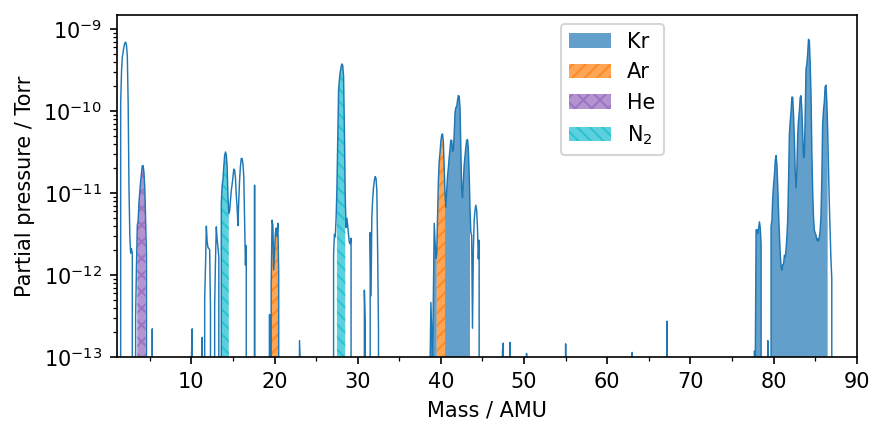

In [10]:
# Insert Filename here!
folder = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/2026_07_30_Kr_separation_replica_2/'
filename = '01_Kr_composition_start.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r''
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/02_replica_Kr_composition_start.png'

print('Pretty Plot Analog')
df = Read_Analog(path)

    
fig = plt.figure(figsize=(6, 3), dpi=150)
ax = fig.add_subplot(111)

list = df.columns

x = df[list[0]]
y = df[list[1]]

ax.plot(x, y, label=r'', linewidth=0.7, alpha=1.0, linestyle="-", color='tab:blue')

ax.fill_between(x, y, where= (37.4<x)&(x<39.6)|(40.4<x)&(x<43.6)|(77.4<x)&(x<86.6), label=r'Kr', 
                color='tab:blue', hatch='', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (19.4<x)&(x<20.6)|(35.4<x)&(x<36.6)|(39.4<x)&(x<40.6), label=r'Ar', 
                color='tab:orange', hatch='////', alpha=0.7, linewidth=0)
#ax.fill_between(x, y, where= (1.4<x)&(x<2.6)|(3.4<x)&(x<4.6), label=r'He', 
#                color='tab:purple', hatch='xxx', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (3.4<x)&(x<4.6), label=r'He', 
                color='tab:purple', hatch='xxx', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (13.4<x)&(x<14.6)|(27.4<x)&(x<28.6), label=r'$\mathrm{N}_2$', 
                color='tab:cyan', hatch='\\\\\\\\', alpha=0.7, linewidth=0)

ax.set_yscale('log')
ax.set_xlim(1,90)
ax.set_ylim(1e-13)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.title(title)
plt.xlabel(r'Mass / AMU')
plt.ylabel(r'Partial pressure / Torr')
plt.legend(loc=(0.6, 0.59), frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()




Pretty Plot PvT
['Hydrogen', 'Helium', 'Dummy-26', 'Nitrogen', 'Oxygen', 'Dummy-34', 'Argon', 'Dummy-42', 'Carbon dioxide', 'Krypton']


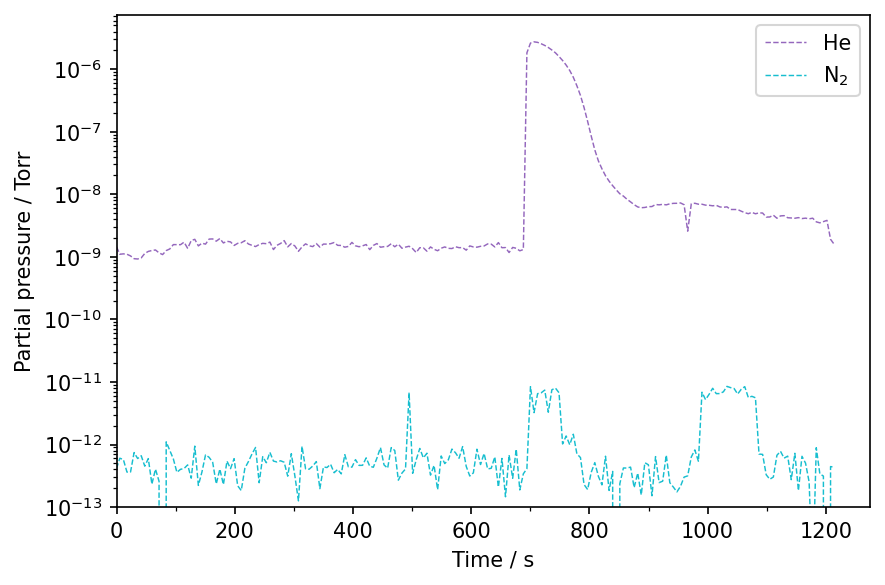

In [11]:
# Insert Filename here!
folder = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/2026_07_30_Kr_separation_replica_2/'
filename = '03_GC_1.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r''
usecols = [2,4,7,8]
usecols = [7,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/02_replica_GC1.png'

print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)
    
print_PvT_2(df, title=title, 
            usecols=usecols, 
            usenames=usenames,
            save_name=save_name)


# Plots for Chapter 4

# Initial Performance:
Using 22 Nov 2024

Pretty Plot PvT
['Hydrogen', 'Helium', 'Dummy-26', 'Nitrogen', 'Oxygen', 'Dummy-34', 'Argon', 'Dummy-42', 'Carbon dioxide', 'Krypton']


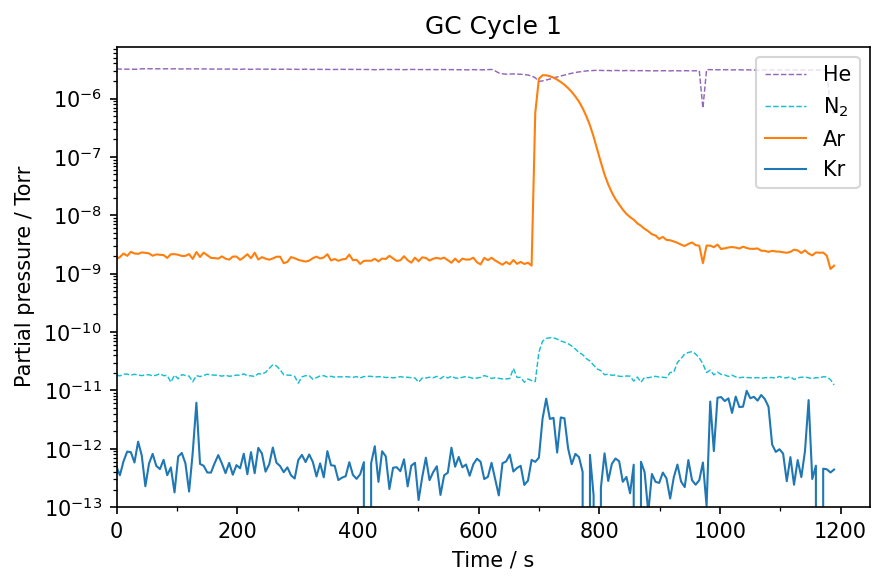

In [17]:
# Initial Performance: GC 1

# Insert Filename here!
folder = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/2026_07_31_Kr_separation_replica_3/'
filename = '03_GC_1.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'GC Cycle 1'
usecols = [2,4,7,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/03_replica_GC1.png'


print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)
    
print_PvT_2(df, title=title, 
            usecols=usecols, 
            usenames=usenames,
            save_name=save_name)


Pretty Plot Analog


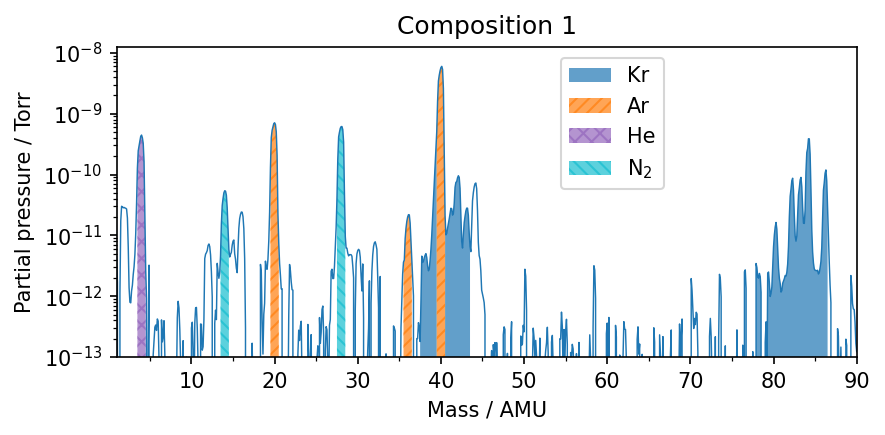

In [44]:
# Initial Performance: Composition 1

# Insert Filename here!
folder = 'Data/2024_11/2024_11_22_Kr-Sep/'
filename = '04_Composition_1.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'Composition 1'
usecols = [2,3,5,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/Initial_Performance_Composition_1'


print('Pretty Plot Analog')
df = Read_Analog(path)
Print_Analog_2(df, title=title,
                save_name=save_name)

Pretty Plot PvT
['Hydrogen', 'Helium', 'Dummy-26', 'Nitrogen', 'Oxygen', 'Argon', 'Carbon dioxide', 'Krypton']


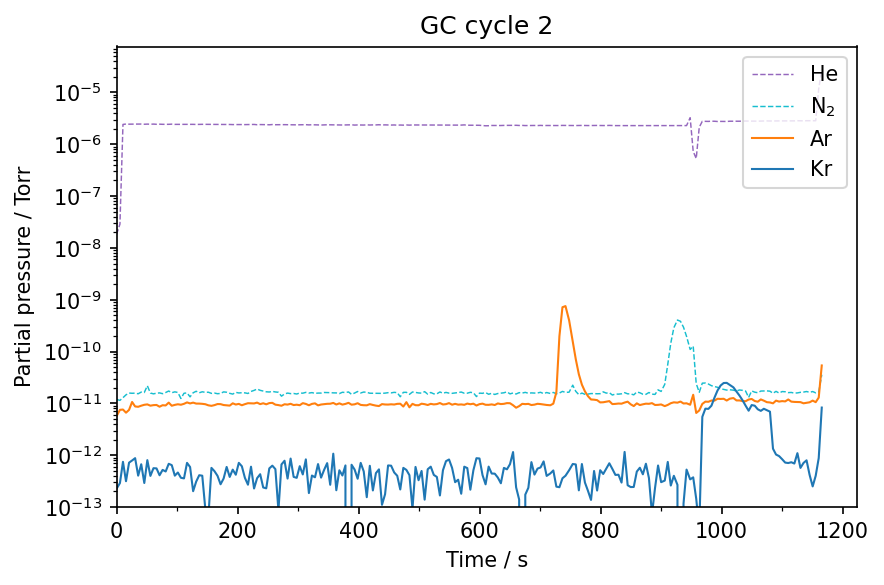

In [12]:
# Initial Performance: GC 2

# Insert Filename here!
folder = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/2026_07_30_Kr_separation_replica_2/'
filename = '05_GC_2.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'GC cycle 2'
usecols = [2,4,6,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/02_replica_GC2.png'


print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)
    
print_PvT_2(df, title=title, 
            usecols=usecols, 
            usenames=usenames,
            save_name=save_name)
    

Pretty Plot Analog


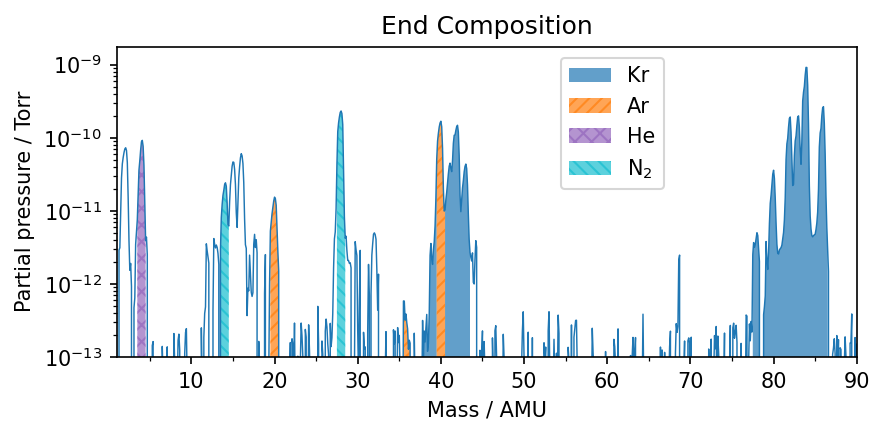

In [13]:
# Initial Performance: Composition 2

# Insert Filename here!
folder = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/2026_07_30_Kr_separation_replica_2/'
filename = '07_Composition_3.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'End Composition'
usecols = [2,3,5,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = '/Users/fatmayakut/Desktop/Physik/MA/Kr-Ar Separation/analysis/2026_08_recovery_for_different_amounts/volume_v_recovery/02_replica_composition_end.png'


print('Pretty Plot Analog')
df = Read_Analog(path)
Print_Analog_2(df, title=title,
                save_name=save_name)

# Capture Times
Using \
29 Nov 2024 (short short) \
02 Dez 2024 (medium short) \
05 Dez 2024 1 (long short) \
05 Dez 2024 2 (long medium) \
04 Dez 2024 (long long)

Pretty Plot PvT
['Hydrogen', 'Helium', 'Nitrogen', 'Oxygen', 'Argon', 'CO2', 'Kr 82', 'Kr 84', 'Kr 86']


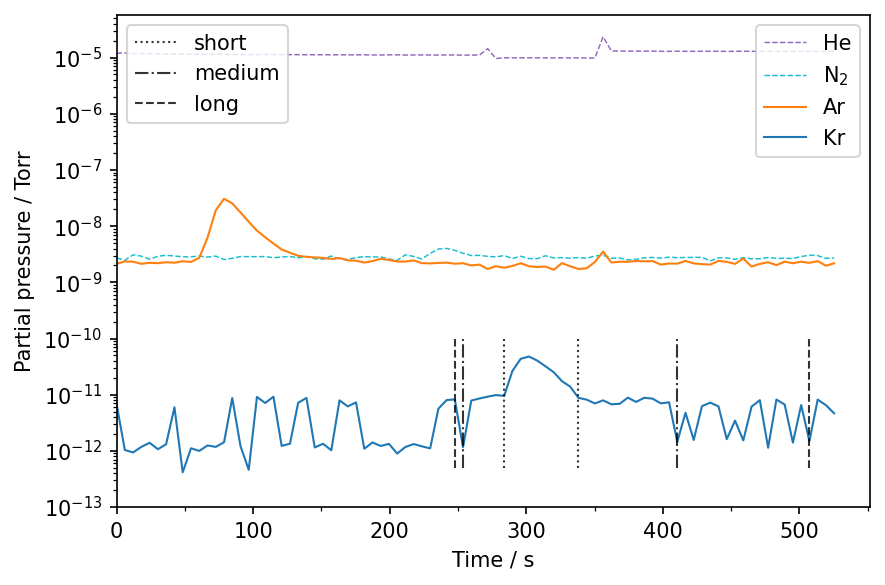

In [47]:
# Indication of switch timings for different capture times

# Insert Filename here!
folder = 'Data/2024_12/2024_12_05_1_Kr-Sep_Long_Short/'
filename = '06_GC_2.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r''
usecols = [2,3,5,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/Capture_Times'


print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)

# Main Plotting (Copied plotter function in order to edit in some extra lines...)
    
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(111)

list = df.columns
x = df[list[0]]

# Plotting calls
for i in range(0, len(usecols)):

    if usenames[i] == 'H2':
        y = df[list[usecols[i]]]
        name = r'$\rm{H_2}$'
        ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle=':', color='tab:green')
    
    if usenames[i] == 'He':
        y = df[list[usecols[i]]]
        name = r'He'
        ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle='--', color='tab:purple')
    
    if usenames[i] == 'N2':
        y = df[list[usecols[i]]]
        name = r'$\rm{N_2}$'
        ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle='--', color='tab:cyan')

    if usenames[i] == 'O2':
        y = df[list[usecols[i]]]
        name = r'$\rm{O_2}$'
        ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle=':', color='tab:pink')

    if usenames[i] == 'Ar':
        y = df[list[usecols[i]]]
        name = r'Ar'
        ax.plot(x, y, label=name, linewidth=1.0, alpha=1.0, linestyle='-', color='tab:orange')

    if usenames[i] == 'CO2':
        y = df[list[usecols[i]]]
        name = r'$\rm{CO_2}$'
        ax.plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle=':', color='tab:grey')

    if usenames[i] == 'Kr':
        y = df[list[usecols[i]]]
        name = r'Kr'
        ax.plot(x, y, label=name, linewidth=1.0, alpha=1.0, linestyle='-', color='tab:blue')

l1 = ax.vlines((x[47], x[56]), 5e-13, 1e-10, linewidth=1.0, alpha=0.8, linestyle=':',  color='black')
l2 = ax.vlines((x[42], x[68]), 5e-13, 1e-10, linewidth=1.0, alpha=0.8, linestyle='-.', color='black')
l3 = ax.vlines((x[41], x[84]), 5e-13, 1e-10, linewidth=1.0, alpha=0.8, linestyle='--', color='black')

legend1 = plt.legend([l1, l2, l3], [r'short', r'medium', r'long'], loc='upper left', frameon=True)
ax.add_artist(legend1)

ax.set_yscale('log')
ax.set_xlim(0)
ax.set_ylim(1e-13)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.title(title)
plt.xlabel(r'Time / s')
plt.ylabel(r'Partial pressure / Torr')
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()
    

    

# Helium Trap

Using 04-06 Feb 2025

Pre:  18.333333333333332 +/- 4.058187882403781
Post: 3.4333333333333336 +/- 1.265789169736502


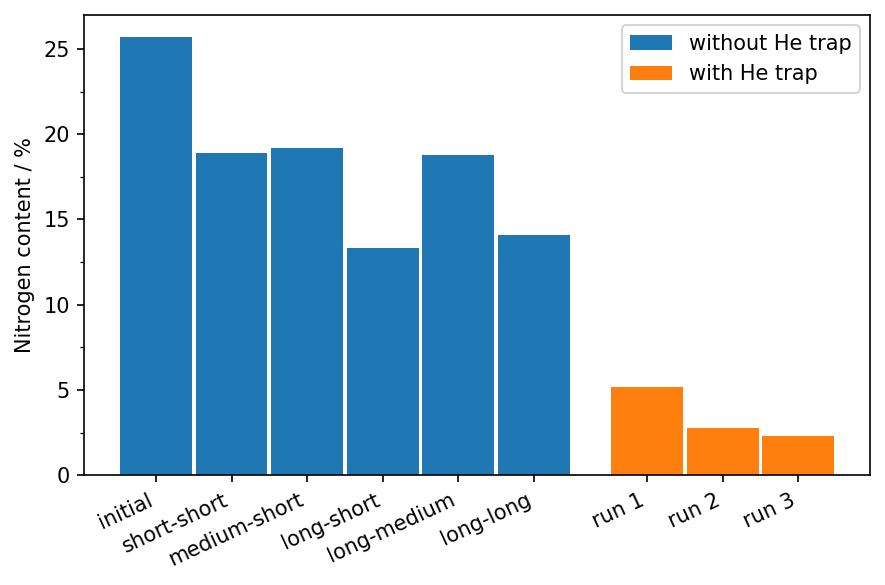

In [48]:
# Bar Chart comparison before vs after He Trap

save_name = 'Output/Chap_4/He-Trap_Comparison'

nitrogen_pre = [25.7, 18.9, 19.2, 13.3, 18.8, 14.1]
nitrogen_post = [5.2, 2.8, 2.3]
nitrogen = nitrogen_pre+nitrogen_post
x = [1,2,3,4,5,6, 7.5,8.5,9.5]
bar_colors = ['tab:blue', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:orange']
bar_names = [r'initial', r'short-short', r'medium-short', r'long-short', r'long-medium', r'long-long', r'run 1', r'run 2', r'run 3']
bar_labels = ['without He trap', '_', '_', '_', '_', '_', 'with He trap', '_', '_']


print('Pre: ', np.mean(nitrogen_pre), '+/-', np.std(nitrogen_pre))
print('Post:', np.mean(nitrogen_post), '+/-', np.std(nitrogen_post))


# Main Plotting (Copied plotter function in order to edit in some extra lines...)
    
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(111)

ax.bar(x=x, height=nitrogen, width=0.95, label=bar_labels, color=bar_colors)

ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_ticks(x, bar_names, rotation=25, ha='right')

#plt.title(title)
plt.xlabel(r'')
plt.ylabel(r'Nitrogen content / %')
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()

# Varying Helium Pressure

Using 12+13 Feb 2025 (1.5, 1.0 and 2.5 bar of helium)\
And 06 Feb 2025 as comparison (2.0 bar of helium)

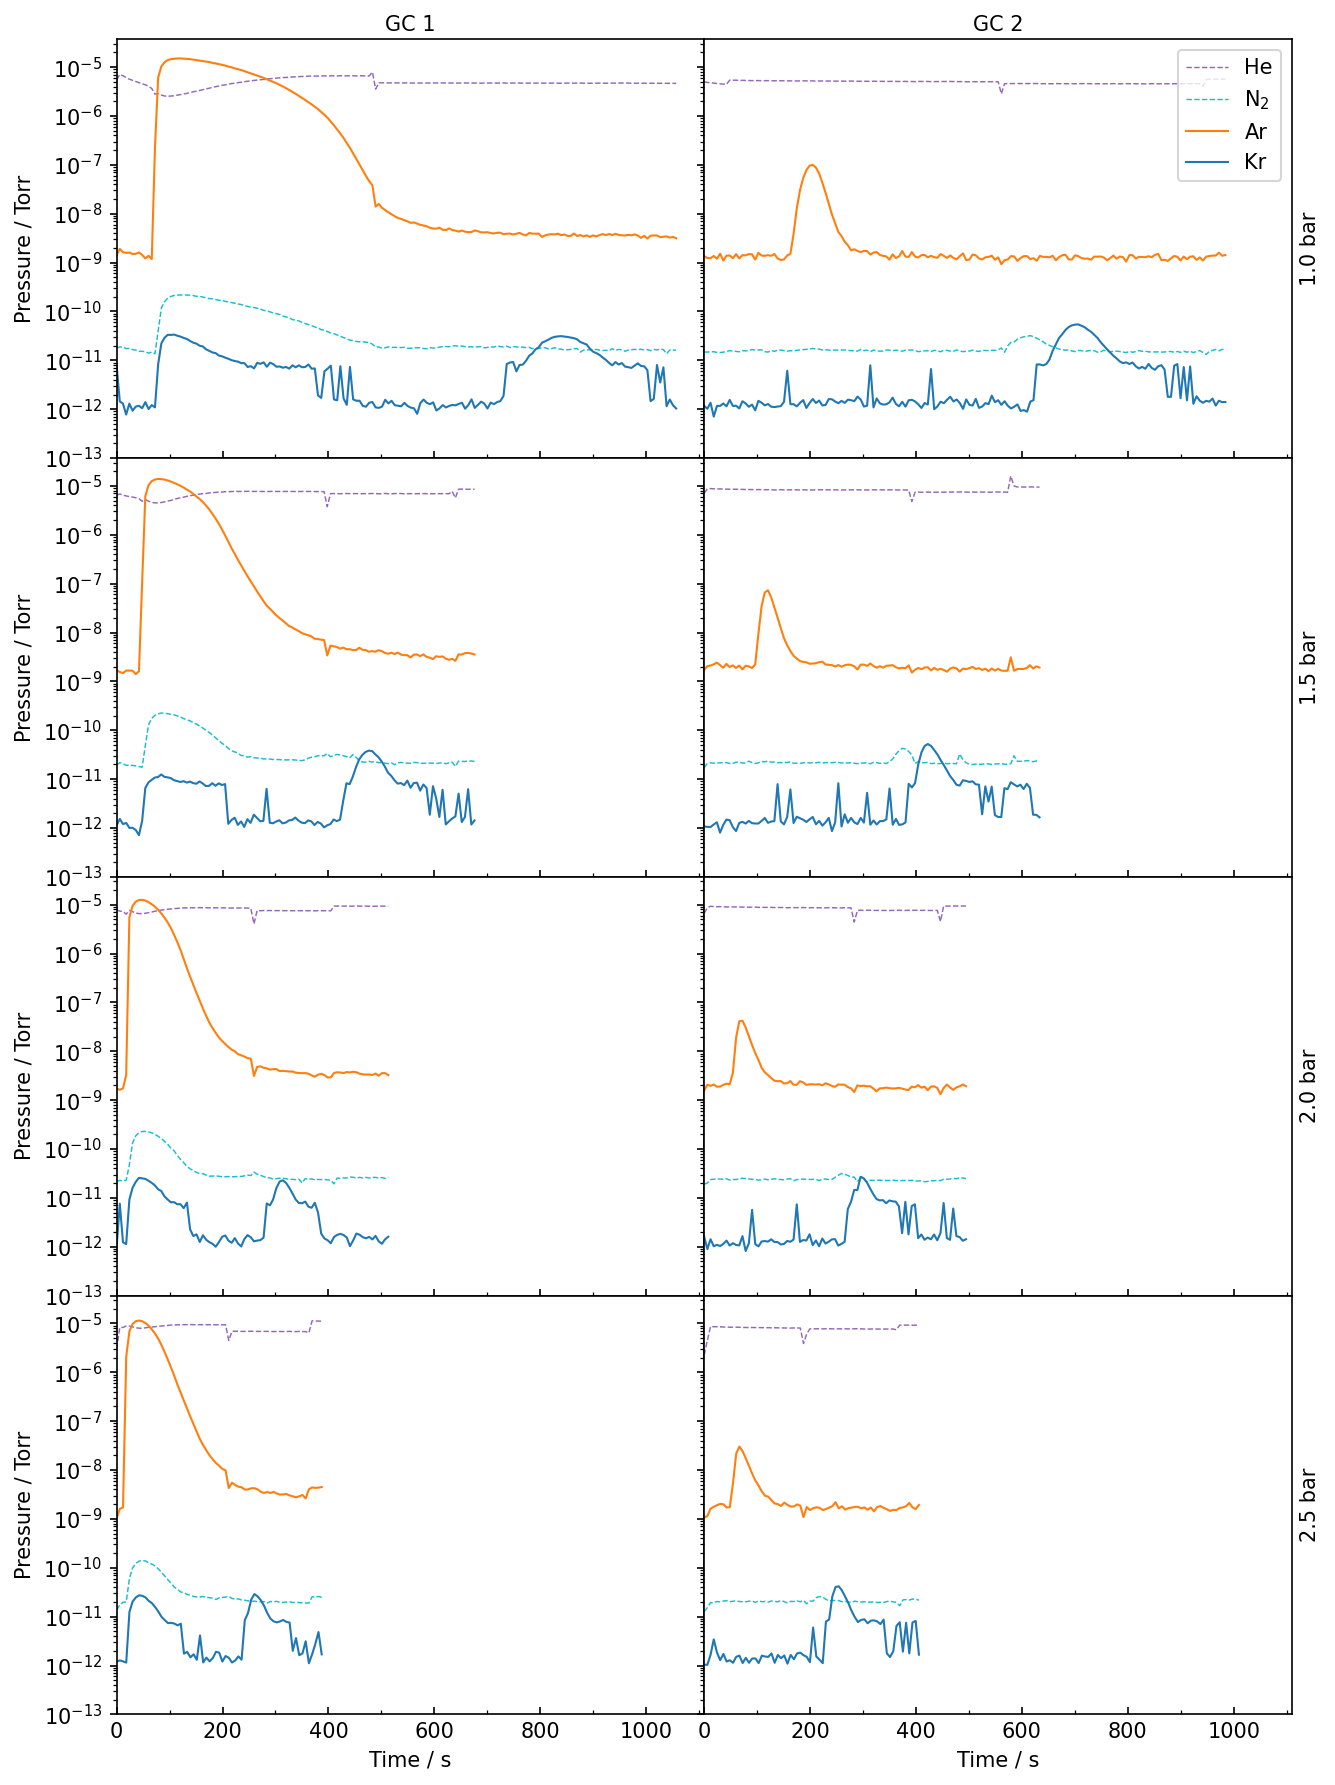

In [49]:
# 8 Plots mit shared axis -> UFF

# Filenames
path10_1 = 'Data/2025_02/2025_02_13_Kr-Sep_10_Helium/03_GC_1.txt'
path15_1 = 'Data/2025_02/2025_02_12_Kr-Sep_15_Helium/03_GC_1.txt'
path20_1 = 'Data/2025_02/2025_02_06_Kr-Sep_extra_Multiplier/03_GC_1.txt'
path25_1 = 'Data/2025_02/2025_02_13_Kr-Sep_25_Helium/03_GC_1.txt'

path10_2 = 'Data/2025_02/2025_02_13_Kr-Sep_10_Helium/06_GC_2.txt'
path15_2 = 'Data/2025_02/2025_02_12_Kr-Sep_15_Helium/06_GC_2.txt'
path20_2 = 'Data/2025_02/2025_02_06_Kr-Sep_extra_Multiplier/06_GC_2.txt'
path25_2 = 'Data/2025_02/2025_02_13_Kr-Sep_25_Helium/06_GC_2.txt'

paths = [path10_1, path10_2, path15_1, path15_2, path20_1, path20_2, path25_1, path25_2]


title = r''
usecols = [2,4,7,10]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = '' #'Output/Chap_4/Helium_Pressures'


fig = plt.figure(figsize=(9, 12), dpi=150)
gs = fig.add_gridspec(4, 2, hspace=0, wspace=0)
(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8) = gs.subplots(sharex=True, sharey=True)
axs = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]

for k, path in enumerate(paths):

    df = Read_PvT(path)
    list=df.columns
    x = df[list[0]]

    # Plotting calls
    for i in range(0, len(usecols)):
        
        if usenames[i] == 'He':
            y = df[list[usecols[i]]]
            name = r'He'
            axs[k].plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle='--', color='tab:purple')
        
        if usenames[i] == 'N2':
            y = df[list[usecols[i]]]
            name = r'$\rm{N_2}$'
            axs[k].plot(x, y, label=name, linewidth=0.7, alpha=1.0, linestyle='--', color='tab:cyan')

        if usenames[i] == 'Ar':
            y = df[list[usecols[i]]]
            name = r'Ar'
            axs[k].plot(x, y, label=name, linewidth=1.0, alpha=1.0, linestyle='-', color='tab:orange')

        if usenames[i] == 'Kr':
            y = df[list[usecols[i]]]
            name = r'Kr'
            axs[k].plot(x, y, label=name, linewidth=1.0, alpha=1.0, linestyle='-', color='tab:blue')

    axs[k].tick_params(which='both', axis='x', direction='in')
    axs[k].xaxis.set_minor_locator(AutoMinorLocator(2))

axs[0].xaxis.set_label_position('top')
axs[0].set_xlabel('GC 1')
axs[1].xaxis.set_label_position('top')
axs[1].set_xlabel('GC 2')

axs[1].yaxis.set_label_position('right')
axs[1].set_ylabel('1.0 bar')
axs[3].yaxis.set_label_position('right')
axs[3].set_ylabel('1.5 bar')
axs[5].yaxis.set_label_position('right')
axs[5].set_ylabel('2.0 bar')
axs[7].yaxis.set_label_position('right')
axs[7].set_ylabel('2.5 bar')

axs[6].set_xlabel(r'Time / s')
axs[7].set_xlabel(r'Time / s')
axs[0].set_ylabel(r'Pressure / Torr')
axs[2].set_ylabel(r'Pressure / Torr')
axs[4].set_ylabel(r'Pressure / Torr')
axs[6].set_ylabel(r'Pressure / Torr')

axs[1].legend(loc='upper right', frameon=True)

plt.yscale('log')
plt.xlim(0)
plt.ylim(1e-13)
plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()

    


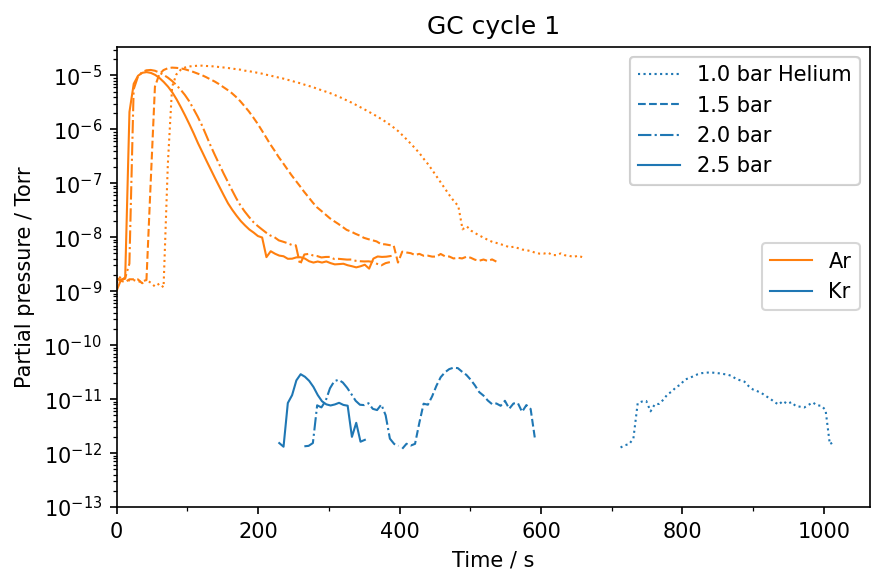

In [50]:
# GC_1 von 4 Geschwindigkeiten übereinander

# Filenames
path10_1 = 'Data/2025_02/2025_02_13_Kr-Sep_10_Helium/03_GC_1.txt'
path15_1 = 'Data/2025_02/2025_02_12_Kr-Sep_15_Helium/03_GC_1.txt'
path20_1 = 'Data/2025_02/2025_02_06_Kr-Sep_extra_Multiplier/03_GC_1.txt'
path25_1 = 'Data/2025_02/2025_02_13_Kr-Sep_25_Helium/03_GC_1.txt'

paths_1 = [path10_1, path15_1, path20_1, path25_1]
ar_start_index_1 = [0, 0, 0, 0]
ar_end_index_1 = [110, 90, 65, 65]
kr_start_index_1 = [118, 67, 44, 38]
kr_end_index_1 = [169, 99, 67, 59]
linestyles=[':', '--', '-.', '-']

title = r'GC cycle 1'
#usecols = [2,4,7,10]
#usenames = ['He', 'N2', 'Ar', 'Kr']
usecols = [7,10]
usenames = ['Ar', 'Kr']
save_name = 'Output/Chap_4/Helium_Pressures_GC_1'


fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(111)

for k, path in enumerate(paths_1):

    df = Read_PvT(path)
    list=df.columns
    x = df[list[0]]

    # Plotting calls
    for i in range(0, len(usecols)):
    
        if usenames[i] == 'Ar':
            y = df[list[usecols[i]]]
            name = r'Ar'
            ax.plot(x[ar_start_index_1[k]:ar_end_index_1[k]], y[ar_start_index_1[k]:ar_end_index_1[k]], label=name, linewidth=1.0, alpha=1.0, linestyle=linestyles[k], color='tab:orange')

        if usenames[i] == 'Kr':
            y = df[list[usecols[i]]]
            name = r'Kr'
            ax.plot(x[kr_start_index_1[k]:kr_end_index_1[k]], y[kr_start_index_1[k]:kr_end_index_1[k]], label=name, linewidth=1.0, alpha=1.0, linestyle=linestyles[k], color='tab:blue')


lines = ax.get_lines()
legend1 = plt.legend([lines[6], lines[7]], [r'Ar', r'Kr'], loc='center right', frameon=True)
ax.add_artist(legend1)
legend2 = plt.legend([lines[1], lines[3], lines[5], lines[7]], [r'1.0 bar Helium', r'1.5 bar', r'2.0 bar', r'2.5 bar'], loc='upper right', frameon=True)
ax.add_artist(legend2)

ax.set_yscale('log')
ax.set_xlim(0)
ax.set_ylim(1e-13)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.title(title)
plt.xlabel(r'Time / s')
plt.ylabel(r'Partial pressure / Torr')

#plt.legend(loc='upper right', frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()

    


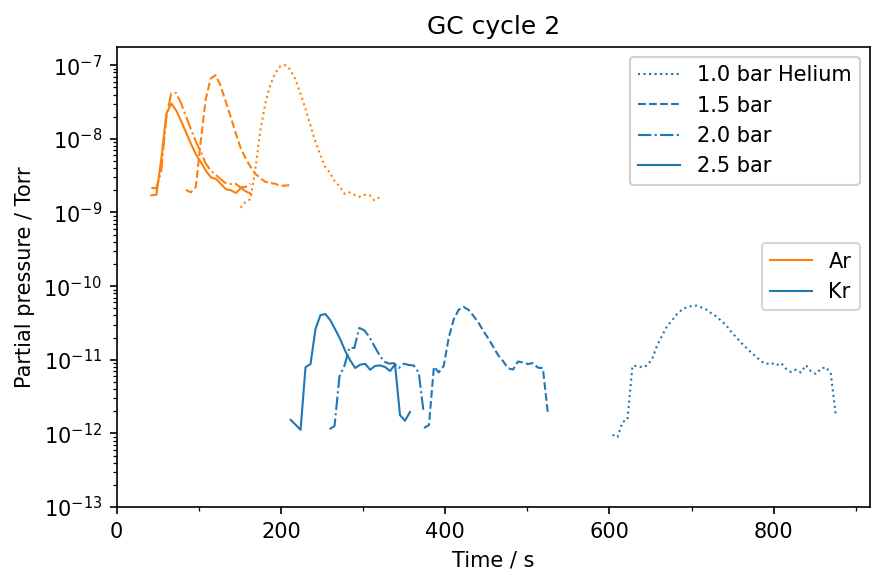

In [51]:
# GC_2 von 4 Geschwindigkeiten übereinander

# Filenames
path10_2 = 'Data/2025_02/2025_02_13_Kr-Sep_10_Helium/06_GC_2.txt'
path15_2 = 'Data/2025_02/2025_02_12_Kr-Sep_15_Helium/06_GC_2.txt'
path20_2 = 'Data/2025_02/2025_02_06_Kr-Sep_extra_Multiplier/06_GC_2.txt'
path25_2 = 'Data/2025_02/2025_02_13_Kr-Sep_25_Helium/06_GC_2.txt'

paths_2 = [path10_2, path15_2, path20_2, path25_2]
ar_start_index_2 =[25, 14, 7, 7]
ar_end_index_2 = [54, 36, 28, 28]
kr_start_index_2 = [100, 62, 43, 35]
kr_end_index_2 = [146, 88, 63, 60]
linestyles=[':', '--', '-.', '-']

title = r'GC cycle 2'
#usecols = [2,4,7,10]
#usenames = ['He', 'N2', 'Ar', 'Kr']
usecols = [7,10]
usenames = ['Ar', 'Kr']
save_name = 'Output/Chap_4/Helium_Pressures_GC_2'


fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(111)

for k, path in enumerate(paths_2):

    df = Read_PvT(path)
    list=df.columns
    x = df[list[0]]

    # Plotting calls
    for i in range(0, len(usecols)):
    
        if usenames[i] == 'Ar':
            y = df[list[usecols[i]]]
            name = r'Ar'
            ax.plot(x[ar_start_index_2[k]:ar_end_index_2[k]], y[ar_start_index_2[k]:ar_end_index_2[k]], label=name, linewidth=1.0, alpha=1.0, linestyle=linestyles[k], color='tab:orange')

        if usenames[i] == 'Kr':
            y = df[list[usecols[i]]]
            name = r'Kr'
            ax.plot(x[kr_start_index_2[k]:kr_end_index_2[k]], y[kr_start_index_2[k]:kr_end_index_2[k]], label=name, linewidth=1.0, alpha=1.0, linestyle=linestyles[k], color='tab:blue')


lines = ax.get_lines()
legend1 = plt.legend([lines[6], lines[7]], [r'Ar', r'Kr'], loc='center right', frameon=True)
ax.add_artist(legend1)
legend2 = plt.legend([lines[1], lines[3], lines[5], lines[7]], [r'1.0 bar Helium', r'1.5 bar', r'2.0 bar', r'2.5 bar'], loc='upper right', frameon=True)
ax.add_artist(legend2)

ax.set_yscale('log')
ax.set_xlim(0)
ax.set_ylim(1e-13)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.title(title)
plt.xlabel(r'Time / s')
plt.ylabel(r'Partial pressure / Torr')
#plt.legend(loc='upper right', frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()

    


# Evacuating the Column

Using 10, 14 and 21 Mar 2025 (3h, 1h 0.5h)

Pre:  2.62 +/- 0.21954498400100142
Post: 16.75 +/- 4.0823114367557345


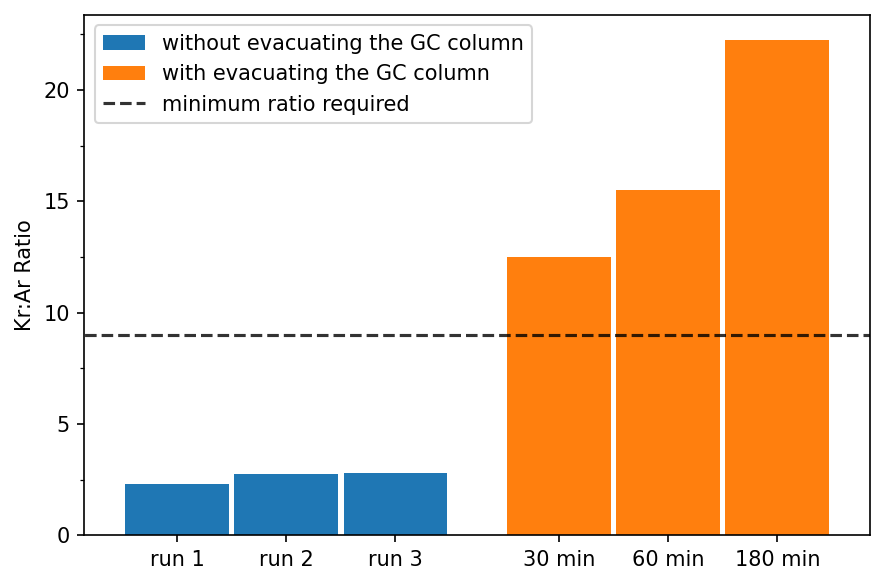

In [52]:
# Bar Chart comparison before vs after Column Evacuation

save_name = 'Output/Chap_4/Evacuating_Column_Comparison'

Ratios_pre = [2.31, 2.76, 2.79]
Ratios_post = [12.48, 15.52, 22.25]
Ratios = Ratios_pre + Ratios_post
x = [1,2,3, 4.5,5.5,6.5]
bar_colors = ['tab:blue', 'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:orange']
bar_names = [r'run 1', r'run 2', r'run 3', r'30 min', r'60 min', r'180 min']
bar_labels = ['without evacuating the GC column', '_', '_', 'with evacuating the GC column', '_', '_']


print('Pre: ', np.mean(Ratios_pre), '+/-', np.std(Ratios_pre))
print('Post:', np.mean(Ratios_post), '+/-', np.std(Ratios_post))


# Main Plotting (Copied plotter function in order to edit in some extra lines...)
    
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = fig.add_subplot(111)

ax.bar(x=x, height=Ratios, width=0.95, label=bar_labels, color=bar_colors)
ax.hlines(9, 0, 7.5, colors='black', alpha=0.8, linestyles='--', label=r'minimum ratio required')

ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_ticks(x, bar_names)#, rotation=25, ha='right')
ax.set_xlim(0.15, 7.35)

#plt.title(title)
plt.xlabel(r'')
plt.ylabel(r'Kr:Ar Ratio')
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()

# Atmospheric test

Using 09 May

In [53]:
# Initial Argon:Krypton ratio in atmosphere:
x = 9.34e-3 / 1.099e-6
x

8498.635122838945

Pretty Plot PvT
['Hydrogen', 'Helium', 'Dummy26', 'Nitrogen', 'Oxygen', 'Dummy34', 'Argon', 'Dummy42', 'CO2', 'Krypton']


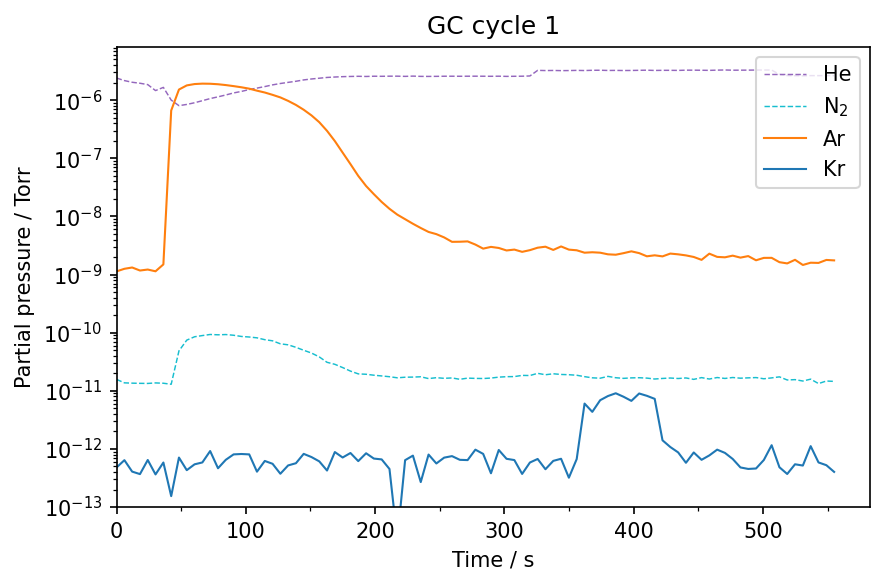

In [54]:
# Atmospheric Test: GC 1

# Insert Filename here!
folder = 'Data/2025_05-07/2025_05_09_Kr-Sep_Argon_Capture_Atmosphere/'
filename = '03_GC_1.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'GC cycle 1'
usecols = [2,4,7,10]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/Atmospheric_GC_1'


print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)
    
print_PvT_2(df, title=title, 
            usecols=usecols, 
            usenames=usenames,
            save_name=save_name)


Pretty Plot Analog


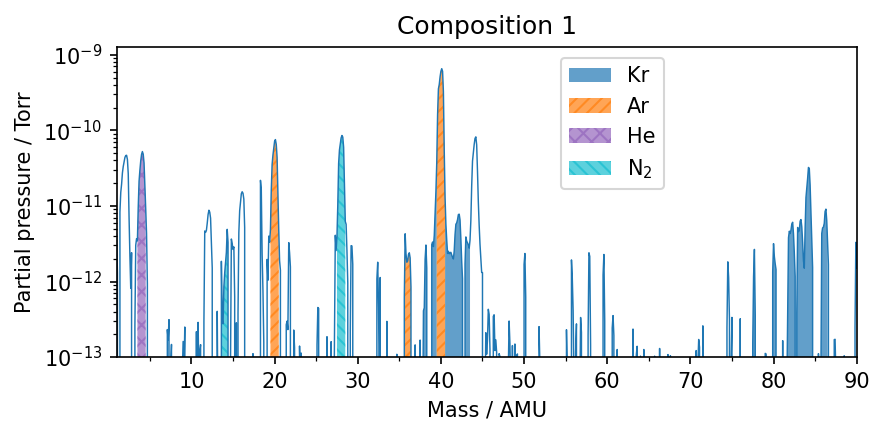

In [55]:
# Atmospheric Test: Composition 1

# Insert Filename here!
folder = 'Data/2025_05-07/2025_05_09_Kr-Sep_Argon_Capture_Atmosphere/'
filename = '04_Composition_Krypton_1.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'Composition 1'
usecols = [2,3,5,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/Atmospheric_Composition_1'


print('Pretty Plot Analog')
df = Read_Analog(path)
Print_Analog_2(df, title=title,
                save_name=save_name)

Pretty Plot PvT
['Hydrogen', 'Helium', 'Dummy26', 'Nitrogen', 'Oxygen', 'Argon', 'CO2', 'Krypton']


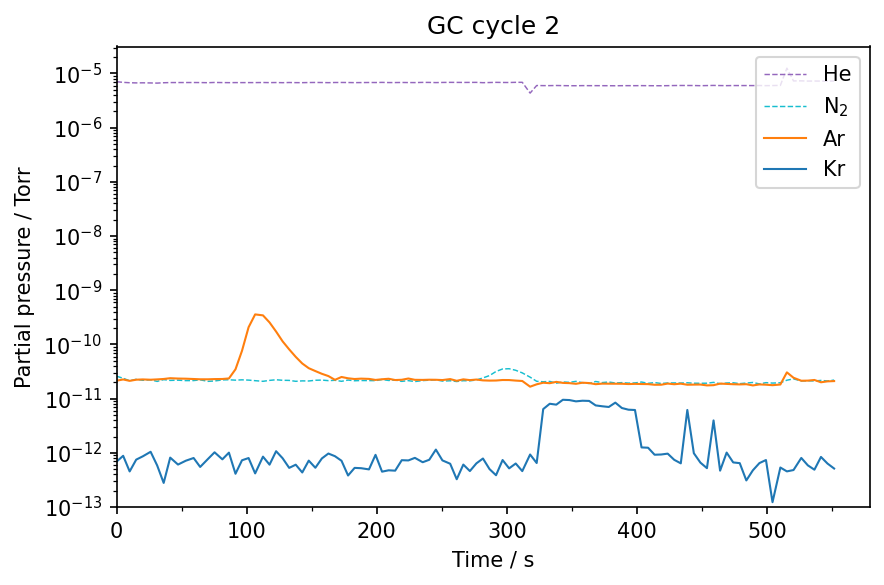

In [56]:
# Atmospheric Test: GC 2

# Insert Filename here!
folder = 'Data/2025_05-07/2025_05_09_Kr-Sep_Argon_Capture_Atmosphere/'
filename = '06_GC_2.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'GC cycle 2'
usecols = [2,4,6,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/Atmospheric_GC_2'


print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)
    
print_PvT_2(df, title=title, 
            usecols=usecols, 
            usenames=usenames,
            save_name=save_name)
    

Pretty Plot Analog


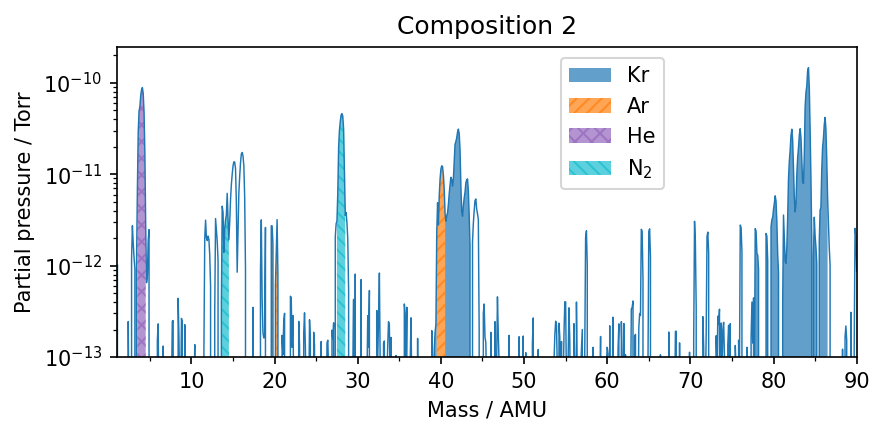

In [57]:
# Armospheric Test: Composition 2

# Insert Filename here!
folder = 'Data/2025_05-07/2025_05_09_Kr-Sep_Argon_Capture_Atmosphere/'
filename = '07_Composition_Krypton_2.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r'Composition 2'
usecols = [2,3,5,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/Atmospheric_Composition_2'


print('Pretty Plot Analog')
df = Read_Analog(path)
Print_Analog_2(df, title=title,
                save_name=save_name)

# ACT-Start Bypass

Using 30 June + 23 July

Pretty Plot PvT
['Hydrogen', 'Helium', 'Dummy-26', 'Nitrogen', 'Oxygen', 'Dummy-34', 'Argon', 'Dummy-42', 'CO2', 'Krypton']


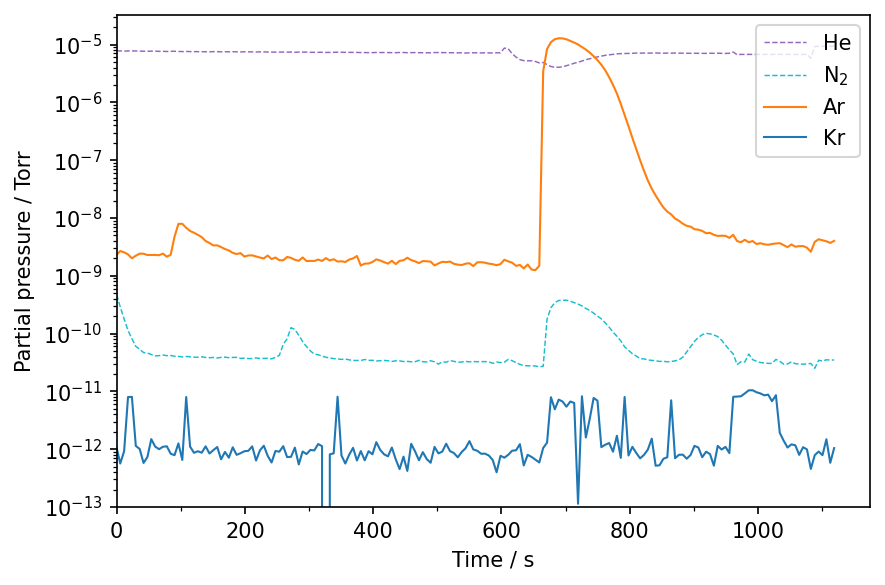

In [58]:
# ACT-Start Bypass: Flushing GC 1

# Insert Filename here!
folder = 'Data/2025_05-07/2025_06_30_Kr-Sep_neue_ACT-Start/'
#folder = 'Data/2025_05-07/2025_07_23_Kr-Sep_lange_He_abumpen/'
filename = '02_GC_1.txt'
#filename = '04_GC_2.txt'


# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r''
usecols = [2,4,7,10]
#usecols = [2,4,6,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/ACT-Start_Bypass_GC_1'


print('Pretty Plot PvT')
df = Read_PvT(path)

names, count = PvT_get_Names(path)
print(names)
    
print_PvT_2(df, title=title, 
            usecols=usecols, 
            usenames=usenames,
            save_name=save_name)

    

# ACT-Kr and -Ar Bypasses

+ Heating Wires
+ Pressure Gauge

Using 29 Okt

Pretty Plot Analog


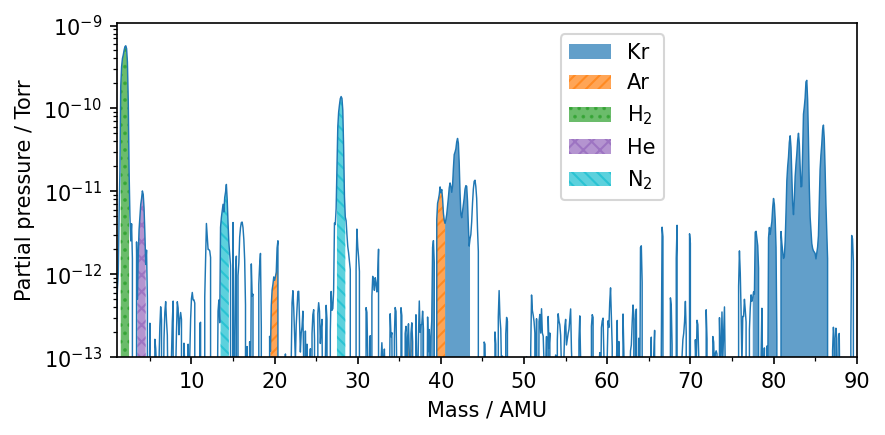

In [59]:
# ACT-Kr + Ar Bypass: Final Composition

# Insert Filename here!
folder = 'Data/2025_08-10/2025_10_29_Kr-Sep_No_Argon_Capture/'
filename = '06_Composition_3.txt'

# Open File, determine Type
path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)

# Do Pretty Plots and Save them
title = r''
usecols = [2,3,5,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = 'Output/Chap_4/ACT-Kr_Ar_Composition_3'


print('Pretty Plot Analog')
df = Read_Analog(path)



# Create a Plot from a given Analog Dataframe
    
fig = plt.figure(figsize=(6, 3), dpi=150)
ax = fig.add_subplot(111)

list = df.columns

x = df[list[0]]
y = df[list[1]]

ax.plot(x, y, label=r'', linewidth=0.7, alpha=1.0, linestyle="-", color='tab:blue')

ax.fill_between(x, y, where= (37.4<x)&(x<39.6)|(40.4<x)&(x<43.6)|(77.4<x)&(x<86.6), label=r'Kr', 
                color='tab:blue', hatch='', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (19.4<x)&(x<20.6)|(35.4<x)&(x<36.6)|(39.4<x)&(x<40.6), label=r'Ar', 
                color='tab:orange', hatch='////', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (1.4<x)&(x<2.6), label=r'$\mathrm{H}_2$', 
                color='tab:green', hatch='...', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (3.4<x)&(x<4.6), label=r'He', 
                color='tab:purple', hatch='xxx', alpha=0.7, linewidth=0)
ax.fill_between(x, y, where= (13.4<x)&(x<14.6)|(27.4<x)&(x<28.6), label=r'$\mathrm{N}_2$', 
                color='tab:cyan', hatch='\\\\\\\\', alpha=0.7, linewidth=0)

ax.set_yscale('log')
ax.set_xlim(1,90)
ax.set_ylim(1e-13)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

plt.title(title)
plt.xlabel(r'Mass / AMU')
plt.ylabel(r'Partial pressure / Torr')
plt.legend(loc=(0.6, 0.47), frameon=True)

plt.tight_layout()

if save_name != '':
    plt.savefig(save_name, dpi=fig.dpi, bbox_inches='tight')

plt.show()

     

# Final Tests

Using 30+31 Okt

In [60]:
# No Plots...

# Overview of used plots

Starting off: 2024_11_22_Kr-Sep \
Capture times: Nov 29 - Dez 05 \
Helium Trap: Feb 04,05,06 \
He Pressure: Feb 12, 13 \
Säule Pumpen: Mar 10,14,21 (21 Mar probably best result Ive had...) \
    Pressure Gauge: Apr 15 \
    First Ar Capture: Mai 06 \
Atmosphere Test: Mai 09 \
Start Bypass: Jun 30 + Jul 23 \
Kr and Ar Bypass: 29 Okt \
Final Tests: 30+31 Okt


Also See: Midterm Vortrag, Plots 3 \

Pretty Plot PvT
['Hydrogen', 'Helium', 'Nitrogen', 'Oxygen', 'Argon', 'CO2', 'Kr 82', 'Kr 84', 'Kr 86']


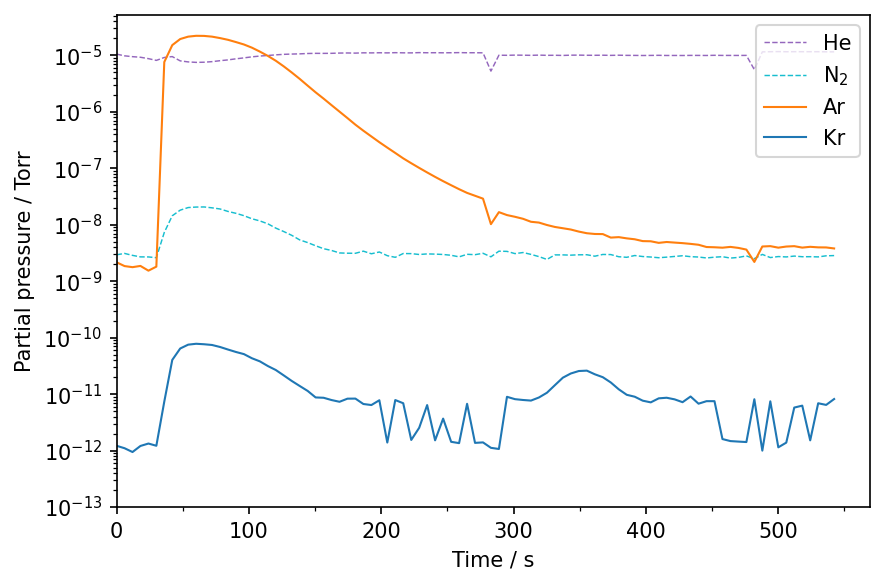

In [61]:
# Template to copy

# Insert Filename here!

folder = 'Data/2024_11/2024_11_22_Kr-Sep/'
filename = '03_GC_1.txt'


# Open File, determine Type

path = folder + filename
Scan_Mode = np.loadtxt(path, dtype=str, skiprows=4, max_rows=1)
Scan_Mode = " ".join(Scan_Mode)


# Do Pretty Plots and Save them

title = r''
usecols = [2,3,5,8]
#usecols = [2,4,6,8]
usenames = ['He', 'N2', 'Ar', 'Kr']
save_name = ''
#save_name = 'Output/Chap_4/Nov_22_GC1.svg'     # svg is very good, png is also good, jpeg is a crime


if Scan_Mode == 'Pressure vs Time Scan Setup:':
    print('Pretty Plot PvT')
    df = Read_PvT(path)

    names, count = PvT_get_Names(path)
    print(names)
    
    print_PvT_2(df, title=title, 
                usecols=usecols, 
                usenames=usenames,
                save_name=save_name)
    
if Scan_Mode == 'Analog Scan Setup:':
    print('Pretty Plot Analog')
    df = Read_Analog(path)
    Print_Analog_2(df, title=title,
                   save_name=save_name)